# Quantitative Scaling of Metabolite Concentration Maps

The measured metabolite maps are **dimensionless** (relative concentrations). To convert them
into physical units (mM), each map is anchored to literature reference values from
Pouwels & Frahm (1998), separated into gray matter (GM) and white matter (WM).

## Tissue fractions

The brain segmentation provides, per voxel, the fraction of its volume that is GM, WM, and CSF.
These sum to one:

$$ f_{GM}(\mathbf{r}) + f_{WM}(\mathbf{r}) + f_{CSF}(\mathbf{r}) = 1 $$

A voxel may be a mixture, e.g. $f_{GM}=0.6,\ f_{WM}=0.1,\ f_{CSF}=0.3$. CSF is
**metabolite-free** ($c_{CSF}=0$), so only GM and WM contribute signal.

## The partial-volume problem

Cortical GM is a thin band bordering CSF. Because the measured maps have a coarser effective
resolution than the segmentation, CSF null-signal bleeds into GM voxels, biasing GM
concentrations downward. This is **not** an outlier or grid problem — it is a structural
partial-volume effect. It is diagnosed by comparing the measured GM/WM ratio to literature:
mixed voxels invert the contrast (GM < WM), while **pure voxels** ($f > 0.8$) recover the
correct literature contrast (GM > WM).

## Scaling strategy

The scaling of the **pure voxels only** is therefore applied. For each metabolite we obtain a
GM and a WM anchor factor and combine them into a single global factor $\alpha$, then apply
it to the whole map:

$$ \alpha_{GM} = \frac{c_{GM}}{\bar m_{GM}^{\text{pure}}}, \qquad
   \alpha_{WM} = \frac{c_{WM}}{\bar m_{WM}^{\text{pure}}}, \qquad
   \alpha = \tfrac{1}{2}\,(\alpha_{GM} + \alpha_{WM}) $$

Linear scaling preserves the distribution shape; only the units change.

In [1]:
import inputs
import file
import tools
import numpy as np

config_file_name = "paths_09012026.json"
configurator = inputs.Configurator(path_folder="../config/",
                                 file_name=config_file_name)
configurator.load()

In [2]:
target_resolution_xyz = (112, 128, 80)
target_gpu_smaller_tasks = 0

## Load the metabolite mask, tissue fractions, and measured concentration maps

The mask is interpolated to the target resolution; the segmentation provides the GM/WM/CSF
partial-volume fractions; the dimensionless concentration maps are loaded as a volume of
shape (metabolite, X, Y, Z). All arrays share the same grid (440, 440, 266).

In [3]:
import numpy as np

# (Mask) Load the metabolite mask and interpolate it to the target resolution (nearest-neighbor, order=0)
metabolic_mask = file.Mask(configurator=configurator)
metabolic_mask.load(mask_name="metabolites", data_type=np.float32)
metabolic_mask.mask.data = tools.InterpolationTools().interpolate(
    array=metabolic_mask.mask.data, target_size=(440, 440, 266), order=0,
    compute_on_device="gpu", return_on_device="cpu", target_gpu=target_gpu_smaller_tasks,
)

# (Tissue fractions) Load GM/WM/CSF partial-volume fractions; they sum to 1 per voxel
fraction_GM  = file.ParameterMaps(configurator, map_type_name="segmentation").load(map_key="segmentations.GM_tissue_fraction")
fraction_WM  = file.ParameterMaps(configurator, map_type_name="segmentation").load(map_key="segmentations.WM_tissue_fraction")
fraction_CSF = file.ParameterMaps(configurator, map_type_name="segmentation").load(map_key="segmentations.CSF_tissue_fraction")
fraction_GM_data  = fraction_GM.loaded_maps["segmentation"]
fraction_WM_data  = fraction_WM.loaded_maps["segmentation"]
fraction_CSF_data = fraction_CSF.loaded_maps["segmentation"]   # not used (CSF is metabolite-free)

# (Measured maps) Map each working name to its dimensionless concentration map file
working_name_and_file_name = {"Glu":     "MetMap_Glu_con_map_TargetRes_HiRes.nii",
                              "Gln":     "MetMap_Gln_con_map_TargetRes_HiRes.nii",
                              "m-Ins":   "MetMap_Ins_con_map_TargetRes_HiRes.nii",
                              "NAA":     "MetMap_NAA_con_map_TargetRes_HiRes.nii",
                              "Cr+PCr":  "MetMap_Cr+PCr_con_map_TargetRes_HiRes.nii",
                              "GPC+PCh": "MetMap_GPC+PCh_con_map_TargetRes_HiRes.nii",
                             }
loaded_concentration_maps = file.ParameterMaps(configurator=configurator, map_type_name="metabolites_concentration")
loaded_concentration_maps.load(
    map_key="maps.metabolites_concentration",
    working_name_and_file_name=working_name_and_file_name,
    data_precision=32,
    verbose=False,
)
# (Volume) Convert to a ParameterVolume of shape (metabolite, X, Y, Z) as float32
concentration_volume = loaded_concentration_maps.to_working(data_type="float32")

# (Check) All arrays must share the same grid
print("concentration:", concentration_volume.maps[0].values.shape)
print("mask:         ", metabolic_mask.mask.data.shape)
print("fraction_GM:  ", fraction_GM_data.shape)
print("fraction_WM:  ", fraction_WM_data.shape)

/tmp/ipykernel_173/560804649.py:4: DeprecationWarning: Mask is deprecated: Use ParameterMaps instead.
  metabolic_mask = file.Mask(configurator=configurator)


[  1  ][ success ] ---v 
                      Loaded file 'Vol_004_mask_slab.nii':
                          Shape             -> (112, 128, 80)
                          Pixel dimensions: -> (1.7188, 1.7188, 1.72)
                          Values range:     -> [0.0, 1.0]
                          Data type:        -> <class 'numpy.float32'>
                          In memory cache?  -> True
[  2  ][ success ] >> NaNs are NOT present!
[  3  ][ success ] >> Thus, loaded the 'metabolites' mask.
[  4  ][  info   ] >> Interpolate on GPU: 0
[  5  ][ success ] ---v  (automatic line breaks)
                      Interpolated on gpu and returned on cpu
                      Shape (112, 128, 80) (4.375 mebibyte) => (440, 440, 266) (196.44775390625
                      mebibyte)
[  6  ][  error  ] >> Could not convert loaded unit 'unknown' to pint unit. Therefore, assigned 'dimensionless'!
[  7  ][ success ] ---v 
                      Loaded 1 volume(s)!
                        names: ['Segm

## Load the literature reference values (Pouwels & Frahm, 1998)

For each metabolite we read the regional GM and WM means and average them (unweighted) into a
single reference mean per compartment:

$$ c_{GM} = \frac{1}{R}\sum_{i=1}^{R} M_{GM,i}, \qquad c_{WM} = \frac{1}{R}\sum_{i=1}^{R} M_{WM,i} $$

where $R$ is the number of sampled regions. This is an across-region average over the Pouwels
regions, not a full-brain volume average.

In [4]:
from inputs import JsonResources
database = JsonResources(path_folder="../resources", file_name="chemical_compounds.json")
database.load()

# (Reference values) Read regional GM/WM means per metabolite from the database
NAA_GM    = database.get_data(key="metabolites.NAA.concentration.Pouwels.GM")
NAA_WM    = database.get_data(key="metabolites.NAA.concentration.Pouwels.WM")
Glu_GM    = database.get_data(key="metabolites.Glu.concentration.Pouwels.GM")
Glu_WM    = database.get_data(key="metabolites.Glu.concentration.Pouwels.WM")
Gln_GM    = database.get_data(key="metabolites.Gln.concentration.Pouwels.GM")
Gln_WM    = database.get_data(key="metabolites.Gln.concentration.Pouwels.WM")
mIns_GM   = database.get_data(key="metabolites.m-Ins.concentration.Pouwels.GM")
mIns_WM   = database.get_data(key="metabolites.m-Ins.concentration.Pouwels.WM")
CrPCr_GM  = database.get_data(key="metabolites.Cr+PCr.concentration.Pouwels.GM")
CrPCr_WM  = database.get_data(key="metabolites.Cr+PCr.concentration.Pouwels.WM")
GPCPCh_GM = database.get_data(key="metabolites.GPC+PCh.concentration.Pouwels.GM")
GPCPCh_WM = database.get_data(key="metabolites.GPC+PCh.concentration.Pouwels.WM")

# (Compartment means) Unweighted average of the regional means -> one GM and one WM value per metabolite
NAA_GM_mean    = sum(v['mean'] for v in NAA_GM.values())    / len(NAA_GM)
NAA_WM_mean    = sum(v['mean'] for v in NAA_WM.values())    / len(NAA_WM)
Glu_GM_mean    = sum(v['mean'] for v in Glu_GM.values())    / len(Glu_GM)
Glu_WM_mean    = sum(v['mean'] for v in Glu_WM.values())    / len(Glu_WM)
Gln_GM_mean    = sum(v['mean'] for v in Gln_GM.values())    / len(Gln_GM)
Gln_WM_mean    = sum(v['mean'] for v in Gln_WM.values())    / len(Gln_WM)
mIns_GM_mean   = sum(v['mean'] for v in mIns_GM.values())   / len(mIns_GM)
mIns_WM_mean   = sum(v['mean'] for v in mIns_WM.values())   / len(mIns_WM)
CrPCr_GM_mean  = sum(v['mean'] for v in CrPCr_GM.values())  / len(CrPCr_GM)
CrPCr_WM_mean  = sum(v['mean'] for v in CrPCr_WM.values())  / len(CrPCr_WM)
GPCPCh_GM_mean = sum(v['mean'] for v in GPCPCh_GM.values()) / len(GPCPCh_GM)
GPCPCh_WM_mean = sum(v['mean'] for v in GPCPCh_WM.values()) / len(GPCPCh_WM)

# (Lookup) Collect the compartment means into dictionaries keyed by map name
lit_GM = {'NAA': NAA_GM_mean, 'Glu': Glu_GM_mean, 'Gln': Gln_GM_mean,
          'm-Ins': mIns_GM_mean, 'Cr+PCr': CrPCr_GM_mean, 'GPC+PCh': GPCPCh_GM_mean}
lit_WM = {'NAA': NAA_WM_mean, 'Glu': Glu_WM_mean, 'Gln': Gln_WM_mean,
          'm-Ins': mIns_WM_mean, 'Cr+PCr': CrPCr_WM_mean, 'GPC+PCh': GPCPCh_WM_mean}

## Diagnose the partial-volume effect

We compare the measured GM/WM contrast against literature in two ways:

1. **All tissue voxels** (any GM/WM fraction) — expected to show the inverted/flattened contrast.
2. **Pure voxels only** ($f > 0.8$) — expected to recover the correct literature contrast.

(!!!) better results when using pure voxels (> 80%) then mixed voxels for estimating the mean

If the contrast recovers on pure voxels, the bias is partial-volume (CSF bleed-in), not a real
acquisition or relaxation effect. This justifies anchoring the scaling on pure voxels.

**Final results:** Showing that it is better to use pure voxels, because then the GM/WM fraction is closer to the literature GM/WM

In [5]:
# (Pure-voxel masks) Voxels that are >0.8 GM or >0.8 WM, i.e. far from CSF borders
pure_GM = metabolic_mask.mask.data * (fraction_GM_data > 0.8)
pure_WM = metabolic_mask.mask.data * (fraction_WM_data > 0.8)

# (All-tissue weights) For comparison: any GM/WM content
weight_GM = metabolic_mask.mask.data * fraction_GM_data
weight_WM = metabolic_mask.mask.data * fraction_WM_data

print("Contrast diagnosis (measured GM/WM vs literature):")
for m in concentration_volume.maps:
    name = m.map_name
    values = m.values

    # all-tissue (fraction-weighted) ratio
    g_all = (values * weight_GM).sum() / weight_GM.sum()
    w_all = (values * weight_WM).sum() / weight_WM.sum()

    # pure-voxel ratio
    sel_g = (pure_GM > 0) & (values > 0)
    sel_w = (pure_WM > 0) & (values > 0)
    g_pure = values[sel_g].mean()
    w_pure = values[sel_w].mean()

    print(f"{name:.<10}: all={g_all/w_all:.2f}  pure={g_pure/w_pure:.2f}  lit={lit_GM[name]/lit_WM[name]:.2f}")

Contrast diagnosis (measured GM/WM vs literature):
Glu.......: all=0.88  pure=1.28  lit=1.30
Gln.......: all=0.95  pure=1.38  lit=2.32
m-Ins.....: all=0.74  pure=1.04  lit=1.19
NAA.......: all=0.76  pure=1.07  lit=1.06
Cr+PCr....: all=0.78  pure=1.10  lit=1.19
GPC+PCh...: all=0.68  pure=0.94  lit=0.69


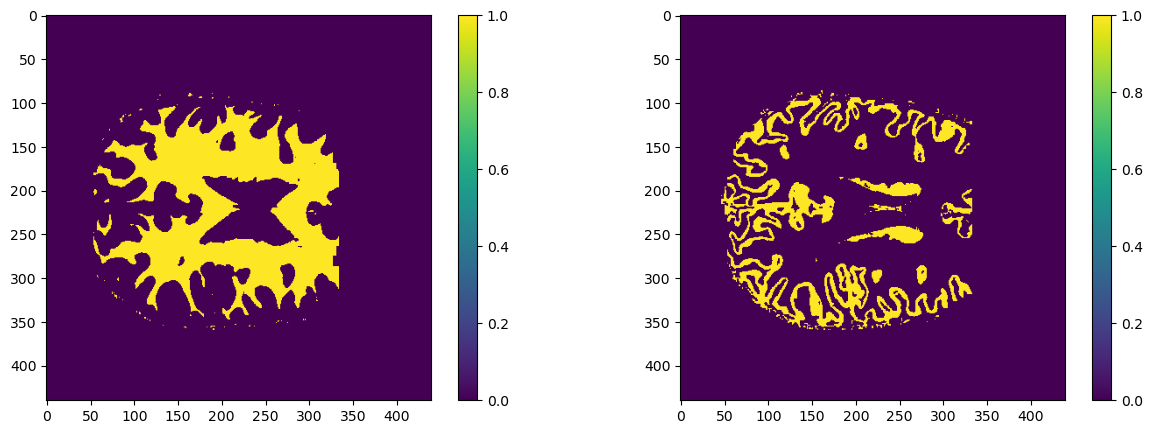

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(pure_WM[:,:, 100])
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(pure_GM[:,:, 100])
plt.colorbar()
plt.show()

## Compute the scaling factor from pure voxels

Pure-voxel anchors avoid the partial-volume downbias. For each metabolite we form a GM and a
WM anchor factor and average them into one global factor:

$$ \alpha = \tfrac{1}{2}\left(\frac{c_{GM}}{\bar m_{GM}^{\text{pure}}} + \frac{c_{WM}}{\bar m_{WM}^{\text{pure}}}\right) $$

The pure-voxel means use the **median** for robustness (outlier trimming proved irrelevant, but
the median is still safer than the mean against any residual skew). A single global factor keeps
the map's intrinsic GM/WM contrast intact rather than overwriting it.

In [6]:
scaling_factor = {}   # one global factor per metabolite

for m in concentration_volume.maps:
    values = m.values
    name   = m.map_name

    # (Pure-voxel anchors) Robust pure-tissue means, free of CSF partial-volume bias
    sel_g = (pure_GM > 0) & (values > 0)
    sel_w = (pure_WM > 0) & (values > 0)
    map_mean_GM = np.median(values[sel_g])
    map_mean_WM = np.median(values[sel_w])

    # (Anchor factors) One per compartment
    factor_GM = lit_GM[name] / map_mean_GM
    factor_WM = lit_WM[name] / map_mean_WM

    # (Global factor) Average of the two pure-voxel anchors
    scaling_factor[name] = 0.5 * (factor_GM + factor_WM)

    print(f"{name:.<10}: global={scaling_factor[name]:.4g} | "
          f"GM-anchor={factor_GM:.4g} WM-anchor={factor_WM:.4g}")

Glu.......: global=1.026 | GM-anchor=1.029 WM-anchor=1.023
Gln.......: global=1.099 | GM-anchor=1.376 WM-anchor=0.8215
m-Ins.....: global=0.637 | GM-anchor=0.6773 WM-anchor=0.5967
NAA.......: global=0.7983 | GM-anchor=0.7904 WM-anchor=0.8062
Cr+PCr....: global=0.8223 | GM-anchor=0.8547 WM-anchor=0.7899
GPC+PCh...: global=0.6821 | GM-anchor=0.5822 WM-anchor=0.7819


## Apply the scaling and verify

Each dimensionless map is multiplied by its global factor, yielding concentrations in mM.
We verify on **pure voxels** that the scaled GM and WM means match the literature values.

Two metabolites are known limitations: **Gln** (low concentration, strong spectral overlap
with Glu, high fit uncertainty) and **GPC+PCh** (the choline composite) may retain a residual
contrast offset that is a quantification limitation, not a scaling error.

**Results showing:** The scaled GM and WM mean for scaled maps and for literature 

In [7]:
# (Apply) Scale each dimensionless map by its global factor -> mM
for m in concentration_volume.maps:
    m.values = m.values * scaling_factor[m.map_name]
    ureg = m.unit._REGISTRY 
    m.unit = ureg.Unit("mM")

concentration_volume.to_volume() # also need to be called once?

# (Verify on pure voxels) Scaled GM/WM means should match literature
print("Verification (pure-voxel scaled mean vs literature):")
for m in concentration_volume.maps:
    name = m.map_name
    sel_g = (pure_GM > 0) & (m.values > 0)
    sel_w = (pure_WM > 0) & (m.values > 0)
    mean_GM = np.median(m.values[sel_g])
    mean_WM = np.median(m.values[sel_w])
    print(f"{name:.<10}: GM={mean_GM:.3g} (lit {lit_GM[name]:.3g}) | "
          f"WM={mean_WM:.3g} (lit {lit_WM[name]:.3g})")

[ 42  ][ success ] ---v  (automatic line breaks)
                      Created stacked volume of the following maps: ['Glu', 'Gln', 'm-Ins', 'NAA',
                      'Cr+PCr', 'GPC+PCh'].
                       Map type: ....... metabolites_concentration
                       Unit: ........... millimolar
                       Shape: .......... (6, 440, 440, 266)
                       Data type: ...... float32
                       Space: .......... 1178.7 mebibyte
Verification (pure-voxel scaled mean vs literature):
Glu.......: GM=8.5 (lit 8.52) | WM=6.58 (lit 6.57)
Gln.......: GM=3.39 (lit 4.25) | WM=2.45 (lit 1.83)
m-Ins.....: GM=4.09 (lit 4.35) | WM=3.91 (lit 3.67)
NAA.......: GM=8.53 (lit 8.45) | WM=7.89 (lit 7.97)
Cr+PCr....: GM=6.45 (lit 6.7) | WM=5.86 (lit 5.63)
GPC+PCh...: GM=1.36 (lit 1.17) | WM=1.48 (lit 1.7)


In [8]:
m.unit

<Unit('millimolar')>

In [9]:
concentration_volume.maps[0].values.mean()

0.98550975

In [23]:
concentration_volume.to_unit("mol/m**3")

[ 211 ][ success ] ---v  (collected several lines)
                      Converted units           'mole / millimeter ** 3' ==> 'mol/m**3'
                      Values range before:      [0      , 4.4e-08]
                      Values range after:       [0      ,      44]
                      
[ 212 ][ success ] ---v  (collected several lines)
                      Converted units           'mole / millimeter ** 3' ==> 'mol/m**3'
                      Values range before:      [0      , 4.5e-08]
                      Values range after:       [0      ,      45]
                      
[ 213 ][ success ] ---v  (collected several lines)
                      Converted units           'mole / millimeter ** 3' ==> 'mol/m**3'
                      Values range before:      [0      , 2.6e-08]
                      Values range after:       [0      ,      26]
                      
[ 214 ][ success ] ---v  (collected several lines)
                      Converted units           'mole / milli

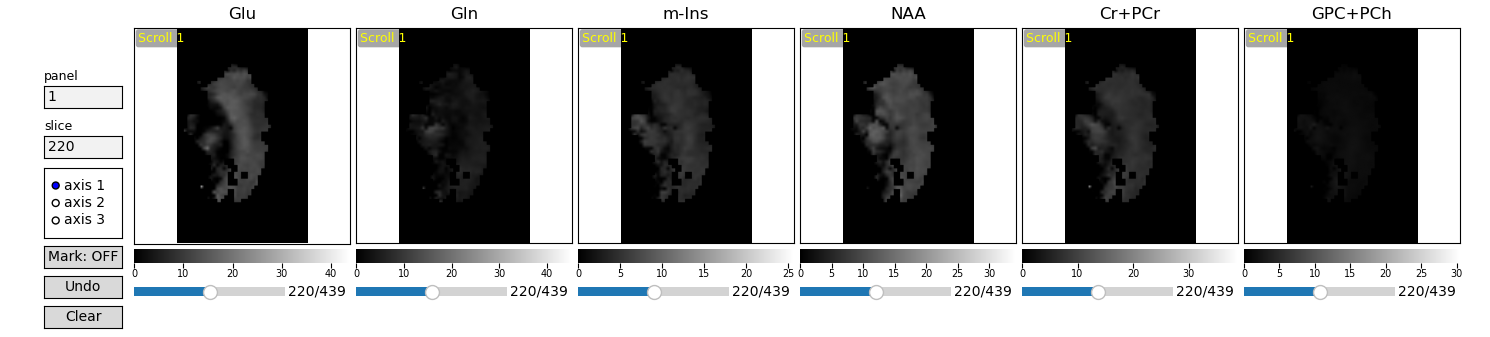

In [25]:
%matplotlib ipympl
concentration_volume.display_jupyter()

In [26]:
concentration_volume.maps[0].values.mean()

0.98550975

In [27]:
concentration_volume.maps[0].map_name

'Glu'

In [22]:
concentration_volume.maps[0].unit

<Unit('mole / millimeter ** 3')>